In [1]:
DATE = 'JUN11'
default_json  = '_json/default_params.json'
controller_mode = 'occupancy'
start = "2023-02-01 00:00"
end   = "2023-03-10 23:00"

In [2]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json

RC_SIMULATOR = "ETHlib"
if RC_SIMULATOR not in sys.path:
    sys.path.insert(0, RC_SIMULATOR)

from _ import *
from _BR_ import *
from _zone_ import DebugZone as Zone
import supply_system
import emission_system
case = RCCase(
    year=2023,
    loc_json              = Path("_json/location_params.json"),
    geo_json              = Path("_json/geo_params.json"),
    default_json          = Path("_json/default_params.json"),
    epw_path              = Path("../src/_base/epw/ED-TMYx.2023.epw"),
    occupancy_profile_csv = Path("ETHlib/auxiliary/schedules_el_OFFICE.csv"),
    Zone=Zone,
    supply_system=supply_system,
    emission_system=emission_system,
)
case.occupancy_profile = (
    pd.read_csv(Path("_data/bldg_LoD.csv"), usecols=["D"])
      .rename(columns={"D": "People"})
      .iloc[:8760]
      .reset_index(drop=True)
)

In [3]:
DEFAULT_PARAMS = json.loads(Path(default_json).read_text())
RUN_DIR = Path(f"_json/_run/{DATE}")
uq_json_path = RUN_DIR / "OAT.json"

meter_path = "_data/Metering_ISO.csv"
meter_daily = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "D",
)
meter_hourly = load_meter_heating(
    meter_path,
    "Main Heating",
    case.geometry["FLOOR_AREA"],
    "h",
)

Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00
Metering Timestamp: 2023-01-01 00:00:00 ~ 2023-12-31 23:00:00


# RUN

In [4]:
from _ import show_progress
from scipy.stats import qmc
def make_lhs_samples_from_uq_json(uq_json_path, N=100, save_csv=True):
    
    uq_json_path = Path(uq_json_path)

    with open(uq_json_path, "r", encoding="utf-8") as f:
        uq_config = json.load(f)

    N = N
    seed = uq_config["seed"]
    params = uq_config["parameters"]

    param_names = list(params.keys())
    n_dim = len(param_names)

    sampler = qmc.LatinHypercube(d=n_dim, seed=seed)
    lhs_unit = sampler.random(n=N)

    samples = pd.DataFrame(index=range(N), columns=param_names, dtype=float)

    for i, name in enumerate(param_names):
        lower = params[name]["lower"]
        upper = params[name]["upper"]

        samples[name] = lower + lhs_unit[:, i] * (upper - lower)

    samples.index = [f"sample_{i+1:03d}" for i in range(N)]

    if save_csv:
        output_path = uq_json_path.parent / f"LHS_samples.csv"
        samples.to_csv(output_path)
        print(f"Saved LHS samples to: {output_path}")

    return samples

def run_lhs_samples(
    lhs_samples,
    controller_mode="occupancy",
):
    results = {}
    euis = {}

    for sample_id, row in show_progress(
        lhs_samples.iterrows(),
        total=len(lhs_samples),
        desc="Running samples",
        unit="sample",
    ):
        sampled_params = row.to_dict()

        res, eui, _ = run_model_case(
            case=case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

In [5]:
lhs_samples= make_lhs_samples_from_uq_json(
uq_json_path=uq_json_path,
N=40
)

lhs_results_occ, lhs_eui_df_occ = run_lhs_samples(
lhs_samples  = lhs_samples,
controller_mode = controller_mode,
)

Saved LHS samples to: _json/_run/JUN11/LHS_samples.csv


Running samples:   0%|          | 0/40 [00:00<?, ?sample/s]

In [6]:
def calc_metrics(sim, obs):
    df = pd.concat(
        [sim.rename("sim"), obs.rename("obs")],
        axis=1,
    ).dropna()

    error = df["obs"] - df["sim"]
    obs_mean = df["obs"].mean()

    cvrmse = np.sqrt(np.mean(error ** 2)) / obs_mean * 100
    nmbe = error.sum() / (len(df) * obs_mean) * 100

    return cvrmse, nmbe


def compare_lhs_to_meter(
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq_label="hourly",
):
    rows = []

    for sample_id, res in lhs_results.items():
        cvrmse, nmbe = calc_metrics(res[variable], meter_series)
        rows.append((sample_id, freq_label, cvrmse, nmbe))

    return pd.DataFrame(
        rows,
        columns=["sample_id", "freq", "cvrmse", "nmbe"],
    ).set_index("sample_id")

In [7]:
KPI = "HeatingEnergy"
temp_res = "D"

meter_series = meter_hourly.resample(temp_res).sum()

lhs_results_res = {
    sample_id: res[[KPI]].resample(temp_res).sum()
    for sample_id, res in lhs_results_occ.items()
}

lhs_metrics_res = compare_lhs_to_meter(
    lhs_results=lhs_results_res,
    meter_series=meter_series,
    variable=KPI,
    freq_label=temp_res,
)

# Training dataset for `calibro`
* temp_res = "H"   # hourly
* temp_res = "D"   # daily
* temp_res = "W"   # weekly
* temp_res = "ME"  # month-end

In [8]:
def save_bayesian_calibration_files(
    lhs_samples,
    lhs_results,
    meter_series,
    variable="HeatingEnergy",
    freq="D",
    start=None,
    end=None,
    output_dir=Path(f"json/UQ/{DATE}_lhs"),
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    TT = lhs_samples.copy()

    def prepare_series(series):
        series = series.copy()

        if start is not None or end is not None:
            series = series.loc[start:end]

        if freq is not None:
            series = series.resample(freq).sum()

        return series

    Y = pd.DataFrame({
        sample_id: prepare_series(res[variable])
        for sample_id, res in lhs_results.items()
    })

    obs = prepare_series(meter_series)
    obs.name = "obs"

    common_index = obs.index.intersection(Y.index)

    obs = obs.loc[common_index]
    Y = Y.loc[common_index]

    # Drop index columns when saving to CSV
    TT.to_csv(output_dir / "TT.csv", index=False)
    Y.to_csv(output_dir / "Y.csv", index=False)
    obs.to_csv(output_dir / "obs.csv", index=False)

    print(f"Saved Bayesian calibration files to: {output_dir}")
    print(f"Period: {obs.index.min()} to {obs.index.max()}")
    print(f"TT shape:  {TT.shape}")
    print(f"Y shape:   {Y.shape}")
    print(f"obs shape: {obs.shape}")

    return TT, Y, obs

KPI = "HeatingEnergy"
temp_res = "D"

output_dir = RUN_DIR / "BC"

TT, Y, obs = save_bayesian_calibration_files(
    lhs_samples=lhs_samples,
    lhs_results=lhs_results_occ,
    meter_series=meter_hourly,
    variable=KPI,
    freq=temp_res,
    start=start,
    end=end,
    output_dir=output_dir,
)

Saved Bayesian calibration files to: _json/_run/JUN11/BC
Period: 2023-02-01 00:00:00 to 2023-03-10 00:00:00
TT shape:  (40, 4)
Y shape:   (38, 40)
obs shape: (38,)


# Execution of `Calibro`

In [9]:
import papermill as pm

NOTEBOOK_IN = "1_CALIBRO.ipynb"

pm.execute_notebook(
    NOTEBOOK_IN,
    f"{DATE}.ipynb",
    parameters={
        "DATE": DATE,
        "START_DATE": start,
        "END_DATE": end,
    },
)


Passed unknown parameter: DATE
Passed unknown parameter: START_DATE
Passed unknown parameter: END_DATE
Input notebook does not contain a cell with tag 'parameters'


Executing:   0%|          | 0/4 [00:00<?, ?cell/s]

Loading required package: R6
Loading required package: coda
Loading required package: parallel
Loading required package: MASS
Loading required package: modeest



### NELDER-MEAD DOWNHILL SIMPLEX ALGORITHM ###

 Version: amoeba
 Start time: 2026-06-14 22:02:48.91809 
 Number of simulations: 5 


*** Simulation 1 / 5 (elapsed time: 0.00117 mins) ***

 best y: 243.803891033431
 best z:
	 %RHO@t_set_heating%@sePar01.pc.mu = 1 
	 %RHO@window_opening_ach%@sePar01.pc.mu = 1 
	 %ALPHA1@sePar01.pc.mu = 1 
	 %SIGMA1@wn1.pc.mu = 0.9998 
	 %SIGMA1@wn2.pc.mu = 88410000 

*** Simulation 2 / 5 (elapsed time: 0.00196 mins) ***

 best y: 266.555905949008
 best z:
	 %RHO@t_set_heating%@sePar01.pc.mu = 0.3182 
	 %RHO@window_opening_ach%@sePar01.pc.mu = 0.007931 
	 %ALPHA1@sePar01.pc.mu = 0.9999 
	 %SIGMA1@wn1.pc.mu = 0.9999 
	 %SIGMA1@wn2.pc.mu = 89120000 

*** Simulation 3 / 5 (elapsed time: 0.00245 mins) ***

 best y: 271.118950876529
 best z:
	 %RHO@t_set_heating%@sePar01.pc.mu = 0.5128 
	 %RHO@window_opening_ach%@sePar01.pc.mu = 0.6622 
	 %ALPHA1@sePar01.pc.mu = 0.9999 
	 %SIGMA1@wn1.pc.mu = 0.9999 
	 %SIGMA1@wn2.pc.mu = 86990000 

*** Simulation 4 / 5 (elap

Warning messages:
1: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 
2: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 
Warning messages:
1: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 
2: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 


processing file: /opt/homebrew/lib/R/4.3/site-library/calibro/calibro_report.Rnw


1/44             
2/44 [setup]     
3/44             
4/44 [exeSumm]   
5/44             
6/44 [content]   
7/44             
8/44 [genVar]    
9/44             
10/44 [dsVar]     
11/44 [dsText]    
12/44             
13/44 [ds1]       
14/44 [ds2]       
15/44 [ds3]       
16/44 [ds4]       
17/44 [ds5]       
18/44 [ds6]       
19/44 [ds7]       
20/44 [ds8]       
21/44 [ds9]       
22/44 [ds10]      
23/44             
24/44 [saVar]     
25/44 [saText]    
26/44             
27/44 [ret_tables]
28/44             
29/44 [train]     
30/44             
31/44 [calVar]    
32/44 [cal]       
33/44 [thetaplot] 
34/44 [ds1fit]    
35/44 [ds2fit]    
36/44 [ds3fit]    
37/44 [ds4fit]    
38/44 [ds5fit]    
39/44 [ds6fit]    
40/44 [ds7fit]    
41/44 [ds8fit]    
42/44 [ds9fit]    
43/44 [ds10fit]   
44/44             


output file: calibro_report.tex



[1] "calibro_report.pdf"


Warning messages:
1: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 
2: encountered a tie, and the difference between minimal and 
                   maximal value is > length('x') * 'tie.limit'
the distribution could be multimodal 


{'cells': [{'id': 'bb9d38ea',
   'cell_type': 'code',
   'metadata': {'tags': ['injected-parameters'],
    'papermill': {'exception': False,
     'start_time': '2026-06-14T21:02:33.373237',
     'end_time': '2026-06-14T21:02:33.391111',
     'duration': 0.017874,
     'status': 'completed'},
    'execution': {'iopub.status.busy': '2026-06-14T21:02:33.380149Z',
     'iopub.execute_input': '2026-06-14T21:02:33.380858Z',
     'iopub.status.idle': '2026-06-14T21:02:33.389598Z',
     'shell.execute_reply': '2026-06-14T21:02:33.388895Z'}},
   'execution_count': 1,
   'source': '# Parameters\nDATE = "JUN11"\nSTART_DATE = "2023-02-01 00:00"\nEND_DATE = "2023-03-10 23:00"\n',
   'outputs': []},
  {'cell_type': 'code',
   'execution_count': 2,
   'metadata': {'tags': [],
    'papermill': {'exception': False,
     'start_time': '2026-06-14T21:02:33.394621',
     'end_time': '2026-06-14T21:02:33.402526',
     'duration': 0.007905,
     'status': 'completed'},
    'execution': {'iopub.status.busy':

In [10]:
import papermill as pm

NOTEBOOK_IN = "1_PLOT_map.ipynb"

pm.execute_notebook(
    NOTEBOOK_IN,
    f"{DATE}.ipynb",
    parameters={
        "DATE": DATE,
        "START_DATE": start,
        "END_DATE": end,
    },
)


Passed unknown parameter: DATE
Passed unknown parameter: START_DATE
Passed unknown parameter: END_DATE
Input notebook does not contain a cell with tag 'parameters'


Executing:   0%|          | 0/1 [00:00<?, ?cell/s]

{'cells': [{'id': 'fb17f68e',
   'cell_type': 'code',
   'metadata': {'tags': ['injected-parameters'],
    'papermill': {'exception': False,
     'start_time': '2026-06-14T21:02:56.477687',
     'end_time': '2026-06-14T21:02:56.496317',
     'duration': 0.01863,
     'status': 'completed'},
    'execution': {'iopub.status.busy': '2026-06-14T21:02:56.483403Z',
     'iopub.execute_input': '2026-06-14T21:02:56.484143Z',
     'iopub.status.idle': '2026-06-14T21:02:56.494708Z',
     'shell.execute_reply': '2026-06-14T21:02:56.493564Z'}},
   'execution_count': 1,
   'source': '# Parameters\nDATE = "JUN11"\nSTART_DATE = "2023-02-01 00:00"\nEND_DATE = "2023-03-10 23:00"\n',
   'outputs': []}],
 'metadata': {'kernelspec': {'display_name': 'eplus_env',
   'language': 'python',
   'name': 'python3'},
  'language_info': {'name': 'python',
   'version': '3.10.4',
   'mimetype': 'text/x-python',
   'codemirror_mode': {'name': 'ipython', 'version': 3},
   'pygments_lexer': 'ipython3',
   'nbconvert_e

# APPENDIX: Code STYLE

Use a configuration-driven functional pandas style.

Package preference:
- Use pathlib.Path for paths.
- Use pandas for tabular data, time-indexed data, resampling, alignment, and CSV output.
- Use numpy only for numerical formulas.
- Avoid classes unless state must be preserved across many methods.
- Avoid creating many intermediate global objects when a function can apply the transformation internally.

Function style:
- Keep functions small and task-specific.
- Pass domain choices as arguments: KPI, frequency, period, output directory.
- Let functions accept base-resolution data, then slice, resample, align, and save internally.
- Avoid hard-coded daily/hourly/heating names inside the function body.
- Avoid default arguments that depend on changing global variables where possible.

DataFrame construction style:
- For fixed summary rows, collect tuples and create one DataFrame with explicit columns.
- For simulation matrices, create a dictionary of aligned Series and pass it once to pd.DataFrame.
- Do not append rows directly to a DataFrame inside a loop.
- Always align simulated and observed data explicitly before metrics or export.

Calling style:
- Define configuration variables once at the call site.
- Use keyword arguments for main workflow functions.
- Do not pre-create daily-specific objects unless they are reused elsewhere.

# Posterior SIM

In [11]:
posterior_TT = f'_json/_run/{DATE}/calibro/posterior_rand10_from_topfrac.csv'
# If posterior_TT is a string (file path)
posterior_TT = pd.read_csv(posterior_TT)

In [12]:
def run_posterior_ecm_samples(
    posterior_TT,
    extra_params=None,
    controller_mode="original",
):
    results = {}
    euis = {}

    if extra_params is None:
        extra_params = {}

    for sample_id, row in show_progress(
        posterior_TT.iterrows(),
        total=len(posterior_TT),
        desc="Running posterior samples",
        unit="sample",
    ):
        sampled_params = row.to_dict()
        sampled_params.update(extra_params)

        res, eui, _ = run_model_case(
            case=case,
            sampled_params=sampled_params,
            controller_mode=controller_mode,
        )

        results[sample_id] = res
        euis[sample_id] = eui

    eui_df = pd.DataFrame(euis).T

    return results, eui_df

# baseline_results, baseline_eui = run_posterior_ecm_samples(
#     posterior_TT=posterior_TT,
#     extra_params=None,
#     controller_mode=controller_mode,
# )

In [ ]:
def make_ecm_specs(case):
    default_win = case.default_params["window_opening_ach"]

    return {
        "Baseline": {},

        "ECM-1_setpoint_19C": {
            "t_set_heating": 19.5,
        },

        "ECM-2_reschedule_8_8_8": {
            "heating_schedule_mode": "8_8_8",
        },

        "ECM-3_setpoint_19C_default_infiltration": {
            "t_set_heating": 19.5,
            "window_opening_ach": default_win,
        },

        "ECM-4_reschedule_8_8_8_default_infiltration": {
            "heating_schedule_mode": "8_8_8",
            "window_opening_ach": default_win,
        },
    }

def run_ecm_suite(
    posterior_TT,
    ecm_specs,
    controller_mode="original",
):
    all_results = {}
    all_euis = {}

    for ecm_name, extra_params in ecm_specs.items():
        results, eui_df = run_posterior_ecm_samples(
            posterior_TT=posterior_TT,
            extra_params=extra_params,
            controller_mode=controller_mode,
        )

        all_results[ecm_name] = results
        all_euis[ecm_name] = eui_df

    return all_results, all_euis

In [14]:
ecm_specs = make_ecm_specs(case)

all_results, all_euis = run_ecm_suite(
    posterior_TT=posterior_TT,
    ecm_specs=ecm_specs,
)

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

Running posterior samples:   0%|          | 0/10 [00:00<?, ?sample/s]

In [15]:
def compute_ecm_savings(
    all_euis,
    baseline_name="Baseline",
    energy_col="HeatingEnergy",
):
    baseline = all_euis[baseline_name][energy_col]
    rows = []

    for ecm_name, eui_df in all_euis.items():
        if ecm_name == baseline_name:
            continue

        df = pd.concat(
            [
                baseline.rename("baseline"),
                eui_df[energy_col].rename("ecm_energy"),
            ],
            axis=1,
            join="inner",
        )

        saving_abs = df["baseline"] - df["ecm_energy"]

        rows.append(
            pd.DataFrame(
                {
                    "ecm": ecm_name,
                    "sample_id": df.index,
                    "saving_abs": saving_abs,
                    "saving_rel": saving_abs / df["baseline"] * 100.0,
                }
            )
        )

    return pd.concat(rows, ignore_index=True)

In [16]:
def plot_ecm_savings_pair(
    savings_df,
    kpi_label="Heating energy",
    abs_unit="kWh m$^{-2}$",
    figsize=(12, 8),
    rot=30,
):
    plot_specs = {
        "saving_abs": (
            f"Absolute {kpi_label.lower()} saving ({abs_unit})",
            f"Absolute {kpi_label.lower()} savings across posterior samples",
        ),
        "saving_rel": (
            f"Relative {kpi_label.lower()} saving (%)",
            f"Relative {kpi_label.lower()} savings across posterior samples",
        ),
    }

    for value_col, (y_label, title) in plot_specs.items():
        fig, ax = plt.subplots(figsize=figsize)

        savings_df.boxplot(
            column=value_col,
            by="ecm",
            ax=ax,
            rot=rot,
        )

        ax.axhline(0, linestyle="--", linewidth=1)
        ax.set_ylabel(y_label)
        ax.set_xlabel("")
        ax.set_title(title)
        ax.grid(True, axis="y", alpha=0.3)

        plt.suptitle("")
        plt.tight_layout()
        plt.show()

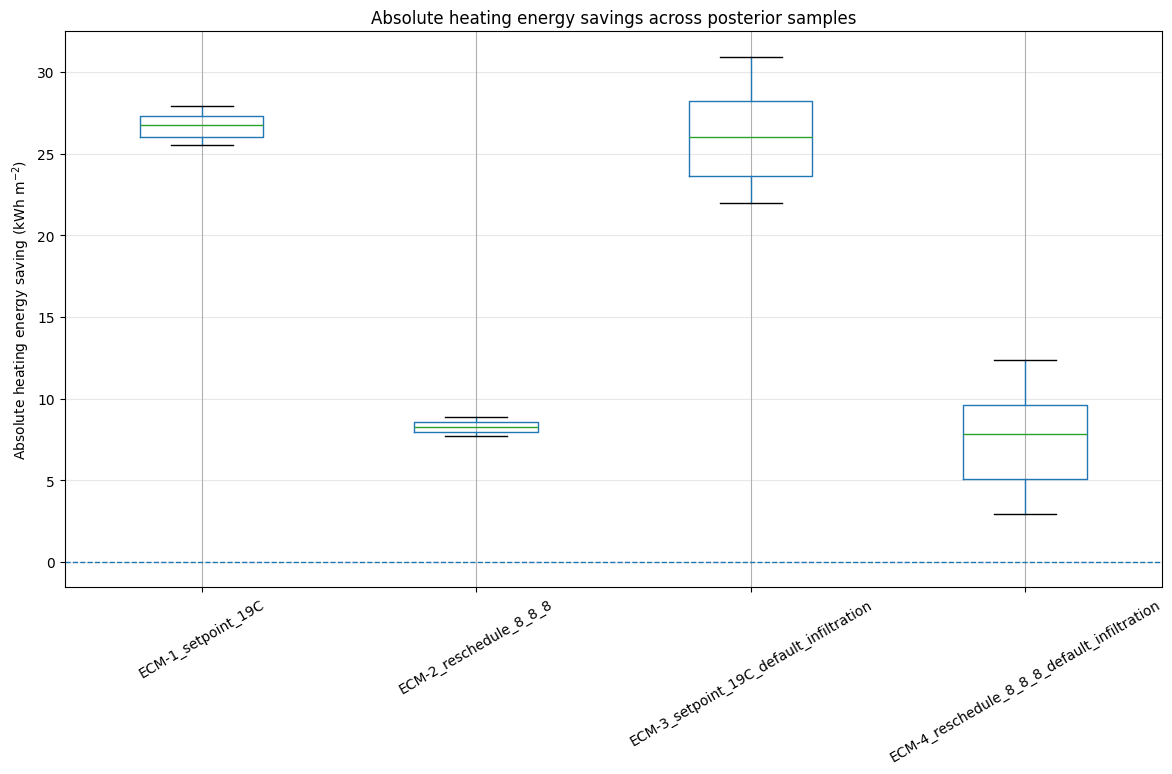

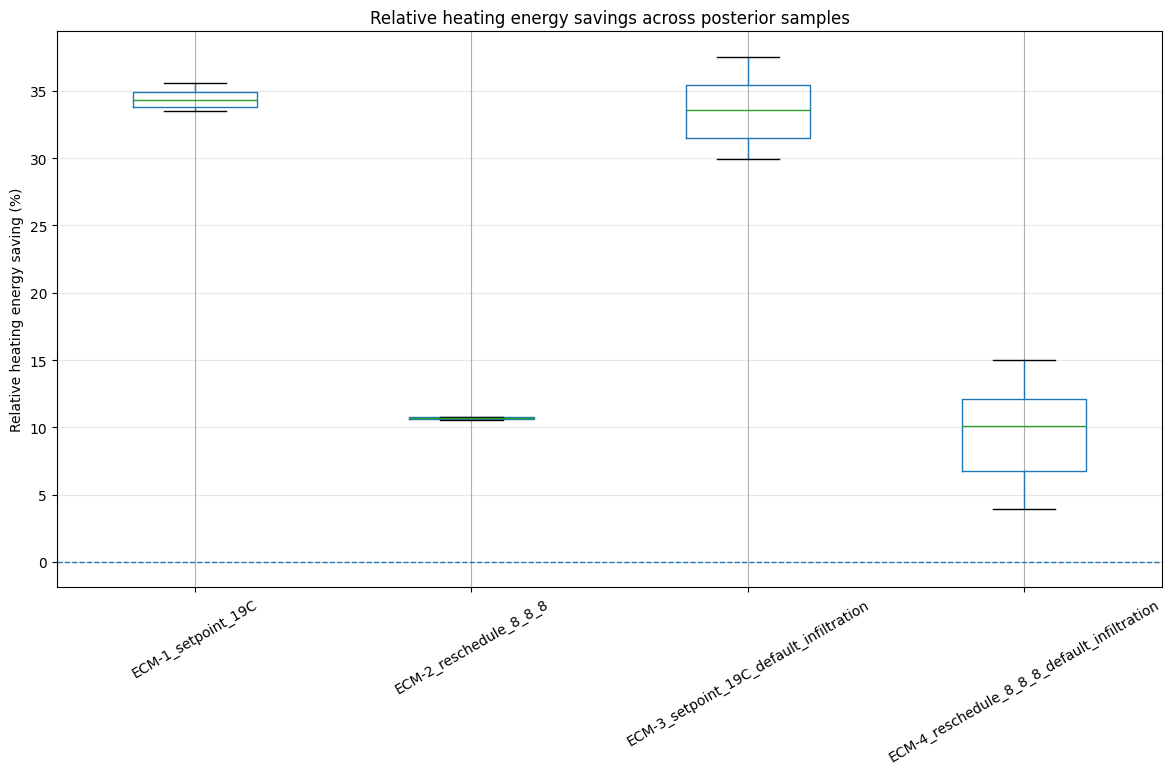

In [17]:
heating_savings = compute_ecm_savings(
    all_euis=all_euis,
    baseline_name="Baseline",
    energy_col="HeatingEnergy",
)

plot_ecm_savings_pair(
    savings_df=heating_savings,
    kpi_label="Heating energy",
)